# 지방간 위험도 예측 모델 학습

전처리된 데이터(nhanes_preprocessed.csv)로 모델 학습, 하이퍼파라미터 튜닝, SHAP 분석까지 수행합니다.

**실행 전**: preprocess.ipynb 먼저 실행

## 1. 환경 설정

In [1]:
import json
import os
import warnings

warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = "../data/nhanes_preprocessed.csv"
MODEL_DIR = "../ai_worker/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("설정 완료")

설정 완료


## 2. 데이터 로드

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"shape: {df.shape}")
df.head()

shape: (15646, 21)


,나이,성별,키,몸무게,BMI,허리둘레,음주여부,1회음주량,주당음주빈도,월폭음빈도,...,주당운동횟수,흡연여부,현재흡연여부,당뇨진단여부,고혈압진단여부,수면장애여부,평균수면시간,식습관자가평가,지방간단계,지방간단계명
0,66.0,여성,158.3,79.5,31.7,101.8,음주함,1.0,0.25,0.0,...,0,흡연경험있음,안함,없음,있음,없음,8.0,보통,0,정상
1,18.0,남성,175.7,66.3,21.5,79.3,음주안함,0.0,0.00,0.0,...,2,흡연경험없음,안함,없음,없음,없음,10.5,좋음,0,정상
2,13.0,남성,158.4,45.4,18.1,64.1,음주함,2.0,0.00,0.0,...,0,흡연경험없음,안함,없음,없음,없음,7.5,보통,0,정상
3,66.0,여성,150.2,53.5,23.7,88.2,음주안함,0.0,0.00,0.0,...,0,흡연경험없음,안함,경계성,있음,없음,8.0,매우좋음,1,경미
4,75.0,여성,151.1,88.8,38.9,113.0,음주함,2.0,0.00,0.0,...,0,흡연경험있음,매일,없음,있음,없음,7.0,보통,2,중등도


## 3. 전처리 설정

In [3]:
TARGET = "지방간단계"
X = df.drop(columns=[TARGET, "지방간단계명"])
y = df[TARGET]

NUMERIC_FEATURES  = ["나이", "키", "몸무게", "BMI", "허리둘레",
                     "1회음주량", "주당음주빈도", "월폭음빈도", "주당운동횟수", "평균수면시간"]
BINARY_FEATURES   = ["성별", "음주여부", "운동여부", "흡연여부", "현재흡연여부",
                     "당뇨진단여부", "고혈압진단여부", "수면장애여부"]
ORDINAL_FEATURES  = ["식습관자가평가"]
FEATURE_NAMES     = NUMERIC_FEATURES + BINARY_FEATURES + ORDINAL_FEATURES

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("bin", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), BINARY_FEATURES),
        ("ord", OrdinalEncoder(categories=[["나쁨", "보통", "좋음"]], handle_unknown="use_encoded_value", unknown_value=-1), ORDINAL_FEATURES),
    ],
    remainder="drop"
)
print("전처리기 정의 완료")

전처리기 정의 완료


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train 분포:\n{y_train.value_counts().sort_index()}")

Train: (12516, 19), Test: (3130, 19)
Train 분포:
지방간단계
0    5109
1    1506
2    2041
3    3860
Name: count, dtype: int64


## 4. 베이스라인 모델 학습 (5-fold CV)

In [13]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
label_names = ["정상", "경도", "중등도", "중증"]

In [12]:
base_models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":      XGBClassifier(n_estimators=200, random_state=42, eval_metric="mlogloss", verbosity=0),
    "LightGBM":     LGBMClassifier(n_estimators=200, random_state=42, verbosity=-1),
}

for name, model in base_models.items():
    # ImbPipeline: SMOTE가 CV의 train fold에만 적용됨 (데이터 누수 방지)
    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", model),
    ])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "pipeline":    pipeline,
        "cv_f1_mean":  cv_scores.mean(),
        "cv_f1_std":   cv_scores.std(),
        "test_acc":    accuracy_score(y_test, y_pred),
        "test_f1":     f1_score(y_test, y_pred, average="weighted"),
        "risk_recall": recall_score(y_test, y_pred, labels=[1, 2, 3], average="macro"),
    }
    print(f"{name}: CV F1={cv_scores.mean():.4f}±{cv_scores.std():.4f} | "
          f"Acc={results[name]["test_acc"]:.4f} | F1={results[name]["test_f1"]:.4f} | "
          f"위험군Recall={results[name]["risk_recall"]:.4f}")


RandomForest: CV F1=0.7607±0.0094 | Acc=0.8176 | F1=0.8158 | 위험군Recall=0.7406
XGBoost: CV F1=0.7425±0.0125 | Acc=0.7792 | F1=0.7758 | 위험군Recall=0.6747
LightGBM: CV F1=0.6882±0.0086 | Acc=0.7067 | F1=0.6980 | 위험군Recall=0.5543


## 5. 하이퍼파라미터 튜닝 (Optuna)

XGBoost 기준으로 튜닝합니다. 결과를 바탕으로 앙상블에 활용합니다.

In [22]:

def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42, "eval_metric": "mlogloss", "verbosity": 0,
    }
    model = Pipeline([("preprocessor", preprocessor), ("classifier", XGBClassifier(**params))])
    return cross_val_score(model, X_train, y_train, cv=3, scoring="f1_weighted", n_jobs=-1).mean()

def objective_lgbm(trial):
    params = {
        "n_estimators":   trial.suggest_int("n_estimators", 100, 500),
        "max_depth":      trial.suggest_int("max_depth", 3, 15),
        "learning_rate":  trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":     trial.suggest_int("num_leaves", 20, 150),
        "subsample":      trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "random_state": 42, "verbosity": -1,
    }
    model = Pipeline([("preprocessor", preprocessor), ("classifier", LGBMClassifier(**params))])
    return cross_val_score(model, X_train, y_train, cv=3, scoring="f1_weighted", n_jobs=-1).mean()

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth":    trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42, "n_jobs": -1,
    }
    model = Pipeline([("preprocessor", preprocessor), ("classifier", RandomForestClassifier(**params))])
    return cross_val_score(model, X_train, y_train, cv=3, scoring="f1_weighted", n_jobs=-1).mean()

best_params = {}
for name, objective in [("XGBoost", objective_xgb), ("LightGBM", objective_lgbm), ("RandomForest", objective_rf)]:
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    best_params[name] = study.best_params
    print(f"\n{name} 최적 파라미터: {study.best_params}")
    print(f"{name} 최적 CV F1: {study.best_value:.4f}")


Best trial: 27. Best value: 0.730388: 100%|██████████| 30/30 [01:54<00:00,  3.82s/it]



XGBoost 최적 파라미터: {'n_estimators': 315, 'max_depth': 9, 'learning_rate': 0.0626586313542883, 'subsample': 0.777725508013676, 'colsample_bytree': 0.8614539135807874, 'min_child_weight': 2}
XGBoost 최적 CV F1: 0.7304


Best trial: 26. Best value: 0.730322: 100%|██████████| 30/30 [02:54<00:00,  5.83s/it]



LightGBM 최적 파라미터: {'n_estimators': 429, 'max_depth': 13, 'learning_rate': 0.037157778514351536, 'num_leaves': 66, 'subsample': 0.8001094757181249, 'colsample_bytree': 0.8523132946867112, 'min_child_samples': 11}
LightGBM 최적 CV F1: 0.7303


Best trial: 22. Best value: 0.734486: 100%|██████████| 30/30 [00:45<00:00,  1.51s/it]


RandomForest 최적 파라미터: {'n_estimators': 104, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}
RandomForest 최적 CV F1: 0.7345


In [ ]:
# 최적화 하이퍼 파라미터 저장
with open(os.path.join(MODEL_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f, indent=4)

In [6]:
# 하이퍼 파라미터 로드
with open(os.path.join(MODEL_DIR, "best_params.json")) as f:
    best_params = json.load(f)

## 6. 앙상블 모델 학습 (Soft Voting / Stacking)

튜닝된 XGBoost를 포함한 앙상블을 구성합니다.

In [14]:
rf_pipe   = ImbPipeline([("preprocessor", preprocessor), ("smote", SMOTE(random_state=42)), ("classifier", RandomForestClassifier(**best_params["RandomForest"]))])
xgb_pipe  = ImbPipeline([("preprocessor", preprocessor), ("smote", SMOTE(random_state=42)), ("classifier", XGBClassifier(**best_params["XGBoost"]))])
lgbm_pipe = ImbPipeline([("preprocessor", preprocessor), ("smote", SMOTE(random_state=42)), ("classifier", LGBMClassifier(**best_params["LightGBM"]))])

# Soft Voting
voting = VotingClassifier(
    estimators=[("rf", rf_pipe), ("xgb", xgb_pipe), ("lgbm", lgbm_pipe)],
    voting="soft", n_jobs=-1,
)
cv_scores = cross_val_score(voting, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)
voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)
results["SoftVoting"] = {
    "pipeline":    voting,
    "cv_f1_mean":  cv_scores.mean(),
    "cv_f1_std":   cv_scores.std(),
    "test_acc":    accuracy_score(y_test, y_pred),
    "test_f1":     f1_score(y_test, y_pred, average="weighted"),
    "risk_recall": recall_score(y_test, y_pred, labels=[1, 2, 3], average="macro"),
}
print(f"SoftVoting: CV F1={cv_scores.mean():.4f}±{cv_scores.std():.4f} | "
      f"Acc={results["SoftVoting"]["test_acc"]:.4f} | F1={results["SoftVoting"]["test_f1"]:.4f} | "
      f"위험군Recall={results["SoftVoting"]["risk_recall"]:.4f}")

# Stacking
stacking = StackingClassifier(
    estimators=[("rf", rf_pipe), ("xgb", xgb_pipe), ("lgbm", lgbm_pipe)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5, n_jobs=-1,
)
cv_scores = cross_val_score(stacking, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)
stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)
results["Stacking"] = {
    "pipeline":    stacking,
    "cv_f1_mean":  cv_scores.mean(),
    "cv_f1_std":   cv_scores.std(),
    "test_acc":    accuracy_score(y_test, y_pred),
    "test_f1":     f1_score(y_test, y_pred, average="weighted"),
    "risk_recall": recall_score(y_test, y_pred, labels=[1, 2, 3], average="macro"),
}
print(f"Stacking:   CV F1={cv_scores.mean():.4f}±{cv_scores.std():.4f} | "
      f"Acc={results["Stacking"]["test_acc"]:.4f} | F1={results["Stacking"]["test_f1"]:.4f} | "
      f"위험군Recall={results["Stacking"]["risk_recall"]:.4f}")


SoftVoting: CV F1=0.7620±0.0113 | Acc=0.8115 | F1=0.8085 | 위험군Recall=0.7163
Stacking:   CV F1=0.7637±0.0059 | Acc=0.8249 | F1=0.8216 | 위험군Recall=0.7316


In [16]:
# 중간 모델 저장 (재학습 없이 로드 가능)
joblib.dump(rf_pipe,   os.path.join(MODEL_DIR, "rf_pipeline.pkl"))
joblib.dump(xgb_pipe,  os.path.join(MODEL_DIR, "xgb_pipeline.pkl"))
joblib.dump(lgbm_pipe, os.path.join(MODEL_DIR, "lgbm_pipeline.pkl"))
joblib.dump(voting,    os.path.join(MODEL_DIR, "voting_pipeline.pkl"))
joblib.dump(stacking,  os.path.join(MODEL_DIR, "stacking_pipeline.pkl"))
print("중간 모델 저장 완료")


중간 모델 저장 완료


In [17]:
# 학습 건너뛰고 저장된 모델 로드
rf_pipe   = joblib.load(os.path.join(MODEL_DIR, "rf_pipeline.pkl"))
xgb_pipe  = joblib.load(os.path.join(MODEL_DIR, "xgb_pipeline.pkl"))
lgbm_pipe = joblib.load(os.path.join(MODEL_DIR, "lgbm_pipeline.pkl"))
voting    = joblib.load(os.path.join(MODEL_DIR, "voting_pipeline.pkl"))
stacking  = joblib.load(os.path.join(MODEL_DIR, "stacking_pipeline.pkl"))
print("모델 로드 완료")


모델 로드 완료


## 7. 전체 성능 비교

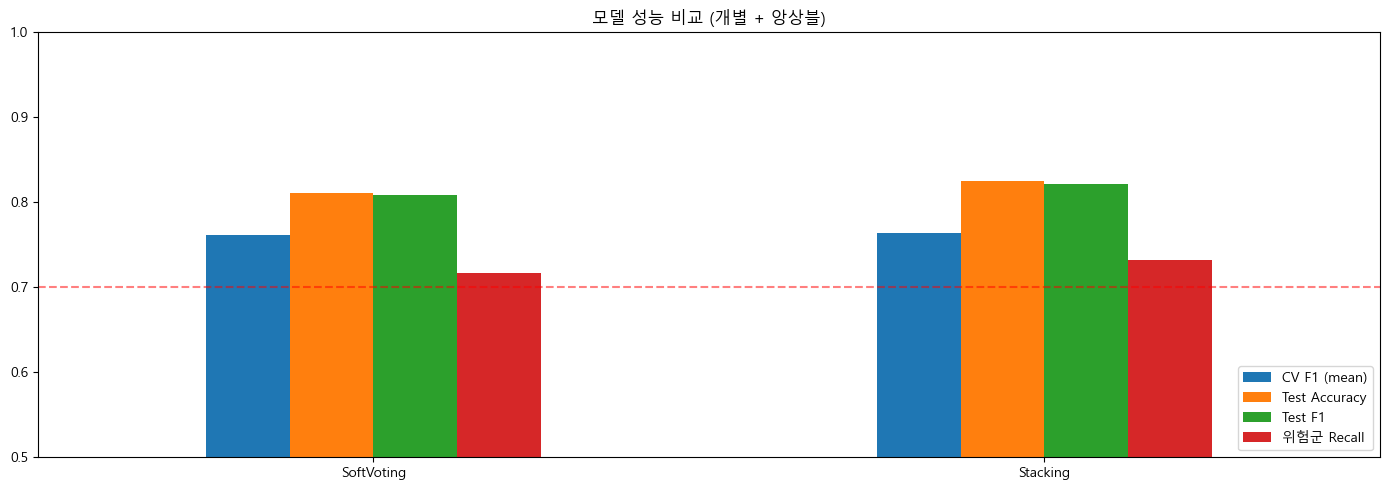

,CV F1 (mean),Test Accuracy,Test F1,위험군 Recall
Stacking,0.763697,0.824920,0.821630,0.731572
SoftVoting,0.762023,0.811502,0.808515,0.716316


In [18]:
result_df = pd.DataFrame({
    name: {
        "CV F1 (mean)":  v["cv_f1_mean"],
        "Test Accuracy": v["test_acc"],
        "Test F1":       v["test_f1"],
        "위험군 Recall":  v["risk_recall"],
    }
    for name, v in results.items()
}).T

result_df.plot(kind="bar", figsize=(14, 5), ylim=(0.5, 1.0))
plt.title("모델 성능 비교 (개별 + 앙상블)")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.axhline(y=0.7, color="red", linestyle="--", alpha=0.5, label="기준선(70%)")
plt.tight_layout()
plt.show()

result_df.sort_values("Test F1", ascending=False)

In [19]:
# 성능 기준: Accuracy >= 70%, 위험군 Recall >= 70%
print("=== 성능 기준 달성 여부 ===")
print(f"{'모델':<15} {'Accuracy':>10} {'위험군Recall':>12} {'기준통과':>8}")
print("-" * 50)
for name, v in results.items():
    acc_ok    = v["test_acc"] >= 0.7
    recall_ok = v["risk_recall"] >= 0.7
    passed    = "✓" if (acc_ok and recall_ok) else "✗"
    print(f"{name:<15} {v['test_acc']:>10.4f} {v['risk_recall']:>12.4f} {passed:>8}")

=== 성능 기준 달성 여부 ===
모델                Accuracy    위험군Recall     기준통과
--------------------------------------------------
SoftVoting          0.8115       0.7163        ✓
Stacking            0.8249       0.7316        ✓


## 8. 최종 모델 선택 및 상세 평가

In [20]:
best_name     = max(results, key=lambda k: results[k]["test_f1"])
best_pipeline = results[best_name]["pipeline"]

print(f"최고 성능 모델: {best_name}")
print(f"Test Accuracy : {results[best_name]['test_acc']:.4f}")
print(f"Test F1       : {results[best_name]['test_f1']:.4f}")
print(f"위험군 Recall  : {results[best_name]['risk_recall']:.4f}")

최고 성능 모델: Stacking
Test Accuracy : 0.8249
Test F1       : 0.8216
위험군 Recall  : 0.7316


In [21]:
y_pred = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_names))

              precision    recall  f1-score   support

          정상       0.86      0.90      0.88      1277
          경도       0.80      0.67      0.73       377
         중등도       0.77      0.64      0.70       511
          중증       0.81      0.88      0.84       965

    accuracy                           0.82      3130
   macro avg       0.81      0.77      0.79      3130
weighted avg       0.82      0.82      0.82      3130



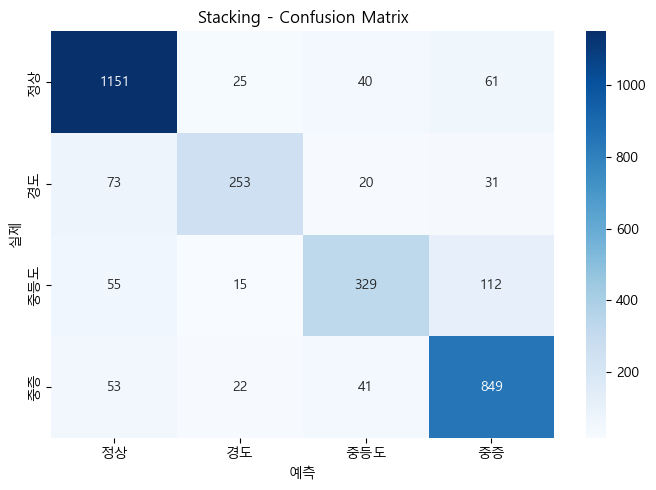

In [36]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title(f"{best_name} - Confusion Matrix")
plt.xlabel("예측")
plt.ylabel("실제")
plt.tight_layout()
plt.show()

## 9. 점수화 (predict_proba → 0~100)

높을수록 위험: 0 ~ 29=중증, 30 ~ 54=중등도, 55 ~ 79=경미, 80~100=정상

점수 통계: mean=53.7, min=10.0, max=93.0


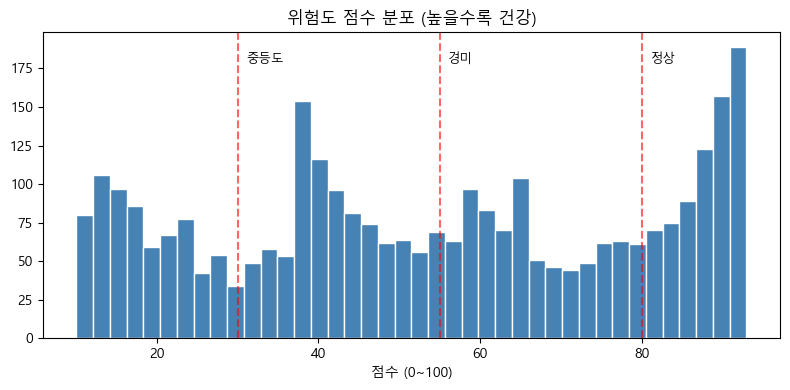

In [43]:
def temperature_scale(proba: np.ndarray, T: float = 2.0) -> np.ndarray:
    """확률을 부드럽게 (T가 클수록 균등하게)"""
    scaled = proba ** (1.0 / T)
    return scaled / scaled.sum()

def proba_to_score(proba: np.ndarray) -> int:
    midpoints = np.array([12.5, 37.5, 62.5, 87.5])
    scaled = temperature_scale(proba, T=1.8)
    raw = float(np.dot(scaled, midpoints))
    score = (87.5 - raw) / 75.0 * 100
    return min(max(10, round(score)), 100)


def score_to_grade(score: int) -> str:
    if score >= 80:
        return "정상"
    elif score >= 55:
        return "경미"
    elif score >= 30:
        return "중등도"
    else:
        return "중증"


probas = best_pipeline.predict_proba(X_test)
scores = np.array([proba_to_score(p) for p in probas])

print(f"점수 통계: mean={scores.mean():.1f}, min={scores.min():.1f}, max={scores.max():.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores, bins=40, color="steelblue", edgecolor="white")
for x, label in [(80, "정상"), (55, "경미"), (30, "중등도")]:
    ax.axvline(x=x, color="red", linestyle="--", alpha=0.6)
    ax.text(x + 1, ax.get_ylim()[1] * 0.9, label, fontsize=9)
ax.set_title("위험도 점수 분포 (높을수록 건강)")
ax.set_xlabel("점수 (0~100)")
plt.tight_layout()
plt.show()


In [40]:
# 점수 변환 단위 테스트
test_cases = [
    (np.array([1.0, 0.0, 0.0, 0.0]), 100, "정상"),
    (np.array([0.0, 1.0, 0.0, 0.0]),  67, "경미"),
    (np.array([0.0, 0.0, 1.0, 0.0]),  33, "중등도"),
    (np.array([0.0, 0.0, 0.0, 1.0]),  10, "중증"),   # 0 → 10으로
    (np.array([0.25, 0.25, 0.25, 0.25]), 50, "중등도"),

]


print("=== 점수 변환 단위 테스트 ===")
all_passed = True
for proba, expected_score, expected_grade in test_cases:
    score = proba_to_score(proba)
    grade = score_to_grade(score)
    passed = score == expected_score and grade == expected_grade
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  {status} | score={score} (기대:{expected_score}) grade={grade} (기대:{expected_grade})")

print(f"\n결과: {'전체 통과' if all_passed else '일부 실패'}")


=== 점수 변환 단위 테스트 ===
  PASS | score=100 (기대:100) grade=정상 (기대:정상)
  PASS | score=67 (기대:67) grade=경미 (기대:경미)
  PASS | score=33 (기대:33) grade=중등도 (기대:중등도)
  PASS | score=10 (기대:10) grade=중증 (기대:중증)
  PASS | score=50 (기대:50) grade=중등도 (기대:중등도)

결과: 전체 통과


In [44]:
test_cases_verbose = [
    ("완전 정상",        np.array([1.0, 0.0, 0.0, 0.0])),
    ("완전 경미",        np.array([0.0, 1.0, 0.0, 0.0])),
    ("완전 중등도",      np.array([0.0, 0.0, 1.0, 0.0])),
    ("완전 중증",        np.array([0.0, 0.0, 0.0, 1.0])),
    ("균등",             np.array([0.25, 0.25, 0.25, 0.25])),
    ("정상 강함",        np.array([0.70, 0.20, 0.07, 0.03])),
    ("정상 약함",        np.array([0.50, 0.30, 0.15, 0.05])),
    ("정상-경미 경계",   np.array([0.45, 0.35, 0.12, 0.08])),
    ("경미 중간",        np.array([0.30, 0.40, 0.20, 0.10])),
    ("경미-중등도 경계", np.array([0.20, 0.30, 0.30, 0.20])),
    ("중등도 중간",      np.array([0.15, 0.20, 0.40, 0.25])),
    ("중등도-중증 경계", np.array([0.10, 0.15, 0.35, 0.40])),
    ("중증 약함",        np.array([0.10, 0.15, 0.30, 0.45])),
    ("중증 강함",        np.array([0.05, 0.05, 0.10, 0.80])),
]

def proba_to_score_raw(proba):
    """T 적용 전 원본"""
    midpoints = np.array([12.5, 37.5, 62.5, 87.5])
    raw = float(np.dot(proba, midpoints))
    score = (87.5 - raw) / 75.0 * 100
    return min(max(10, round(score)), 100)

print(f"{'케이스':20} {'T=1(원본)':>10} {'T=1.8':>8} {'변화':>6}")
print("-" * 50)
for label, proba in test_cases_verbose:
    before = proba_to_score_raw(proba)
    after  = proba_to_score(proba)  # T=2.0 적용된 함수
    print(f"{label:20} {before:>8}점  {after:>6}점  ({after-before:+d})")


케이스                     T=1(원본)    T=1.8     변화
--------------------------------------------------
완전 정상                     100점     100점  (+0)
완전 경미                      67점      67점  (+0)
완전 중등도                     33점      33점  (+0)
완전 중증                      10점      10점  (+0)
균등                         50점      50점  (+0)
정상 강함                      86점      73점  (-13)
정상 약함                      75점      66점  (-9)
정상-경미 경계                   72점      64점  (-8)
경미 중간                      63점      58점  (-5)
경미-중등도 경계                  50점      50점  (+0)
중등도 중간                     42점      45점  (+3)
중등도-중증 경계                  32점      39점  (+7)
중증 약함                      30점      38점  (+8)
중증 강함                      12점      27점  (+15)


## 10. SHAP 분석

ERD의 `predictions.shap_factors`와 `challenges.shap_feature`에 활용됩니다.
상위 3개 위험 요인을 추출합니다.

In [27]:

# 전처리기 추출
if isinstance(best_pipeline, Pipeline):
    preprocessor_fitted = best_pipeline["preprocessor"]
    classifier = best_pipeline.named_steps["classifier"]
else:
    first_pipe = best_pipeline.estimators_[0]
    preprocessor_fitted = first_pipe["preprocessor"]
    classifier = None

if classifier and hasattr(classifier, "feature_importances_"):
    # 개별 트리 모델: 전처리된 데이터로 TreeExplainer
    X_test_transformed = preprocessor_fitted.transform(X_test)
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_transformed)
    print(f"SHAP values shape: {np.array(shap_values).shape}")
    print("TreeExplainer 적용 완료")
else:
    print("앙상블 모델 → KernelExplainer 사용 (샘플 50개, 시간 소요)")
    feature_names = X_test.columns.tolist()

    def predict_proba_df(X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=feature_names)
        return best_pipeline.predict_proba(X)

    background_df = X_test.sample(50, random_state=42)
    explainer = shap.KernelExplainer(predict_proba_df, background_df)
    shap_values = explainer.shap_values(X_test.iloc[:100])

    print("KernelExplainer 적용 완료")



앙상블 모델 → KernelExplainer 사용 (샘플 50개, 시간 소요)


100%|██████████| 100/100 [07:58<00:00,  4.79s/it]

KernelExplainer 적용 완료


shap_arr.shape: (100, 19, 4)


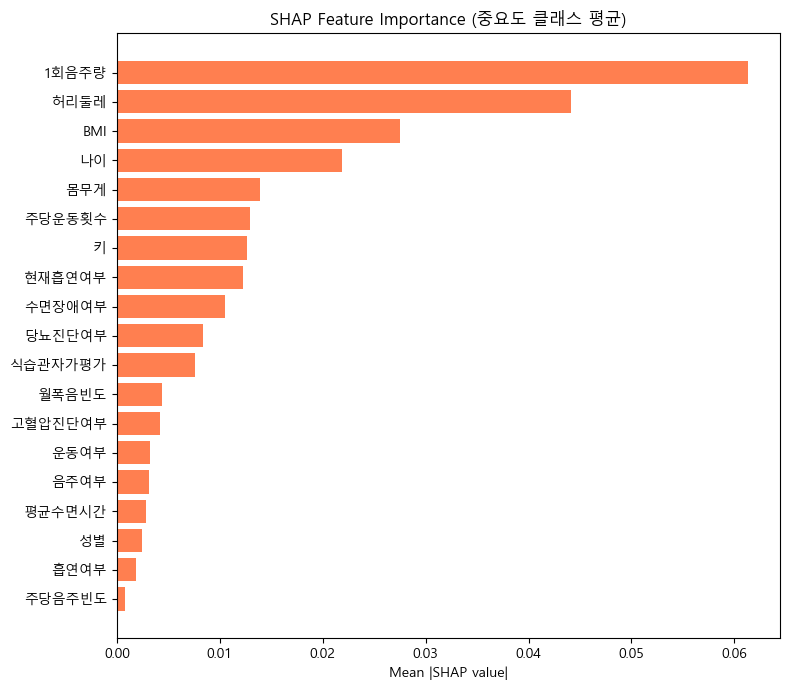

In [29]:
# SHAP Summary Plot
shap_arr = np.array(shap_values)
print(f"shap_arr.shape: {shap_arr.shape}")  # 확인용

if shap_arr.ndim == 3:
    if shap_arr.shape[2] == len(FEATURE_NAMES):
        # (n_classes, n_samples, n_features) — KernelExplainer
        shap_importance = np.abs(shap_arr[1:]).mean(axis=(0, 1))
    elif shap_arr.shape[1] == len(FEATURE_NAMES):
        # (n_samples, n_features, n_classes) — TreeExplainer (newer shap)
        shap_importance = np.abs(shap_arr[:, :, 1:]).mean(axis=(0, 2))
    else:
        raise ValueError(f"shap_arr.shape={shap_arr.shape}, FEATURE_NAMES len={len(FEATURE_NAMES)}")
elif shap_arr.ndim == 2:
    shap_importance = np.abs(shap_arr).mean(axis=0)
else:
    raise ValueError(f"예상치 못한 shap_arr.ndim={shap_arr.ndim}")

shap_df = pd.DataFrame({"feature": FEATURE_NAMES, "shap_importance": shap_importance})
shap_df = shap_df.sort_values("shap_importance", ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(shap_df["feature"], shap_df["shap_importance"], color="coral")
plt.title("SHAP Feature Importance (중요도 클래스 평균)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()


In [31]:
from sklearn.pipeline import Pipeline


def get_shap_factors(pipeline, input_df: pd.DataFrame, explainer_obj, feature_names: list, top_n: int = 3) -> list[dict]:
    if isinstance(pipeline, Pipeline):
        prep = pipeline["preprocessor"]
    else:
        prep = pipeline.estimators_[0]["preprocessor"]

    # 1. 데이터를 변환합니다.
    X_transformed = prep.transform(input_df)

    # 2. 데이터 타입을 float64로 강제 변환하여 넘파이 배열로 만듭니다.
    # 만약 여기서 에러가 난다면 전처리기에서 문자열이 숫자로 바뀌지 않은 것입니다.
    if hasattr(X_transformed, "toarray"): # 희소 행렬(Sparse Matrix)인 경우 대응
        X_transformed = X_transformed.toarray()

    X_transformed = np.array(X_transformed, dtype=np.float64)

    # 3. SHAP 값 계산
    sv = explainer_obj.shap_values(X_transformed)
    sv_arr = np.array(sv)

    if sv_arr.ndim == 3:
        # 이진 분류일 경우 (n_samples, n_features, n_outputs) 구조일 수 있음
        # 사용자가 원하는 클래스의 인덱스를 선택해야 합니다. (여기서는 index 1 가정)
        sample_shap = sv_arr[1, 0, :] if sv_arr.shape[0] == 2 else sv_arr[0, 0, :]
    else:
        sample_shap = sv_arr[0]

    top_indices = np.argsort(np.abs(sample_shap))[::-1][:top_n]
    factors = []
    for idx in top_indices:
        factors.append({
            "feature":    feature_names[idx],
            "value":      float(input_df.iloc[0][feature_names[idx]]),
            "shap_value": round(float(sample_shap[idx]), 4),
            "direction":  "위험" if sample_shap[idx] > 0 else "보호",
        })
    return factors

## 11. 모델 저장 및 서빙 준비

In [33]:
import json
import os

import joblib
import shap

# 경로 설정
MODEL_PATH     = os.path.join(MODEL_DIR, "fatty_liver_model.pkl")
META_PATH      = os.path.join(MODEL_DIR, "model_meta.json")
EXPLAINER_PATH = os.path.join(MODEL_DIR, "shap_explainer.bin") # 확장자를 .bin으로 권장

# 1. 모델 저장 (Pipeline은 joblib 가능)
joblib.dump(best_pipeline, MODEL_PATH)

# 2. SHAP Explainer 저장 (자체 메서드 사용)
# joblib.dump 대신 아래 방식을 사용해야 TypeError를 피할 수 있습니다.
with open(EXPLAINER_PATH, "wb") as f:
    explainer.save(f)

# 3. 메타 정보 저장 (기존과 동일)
meta = {
    "model_name":       best_name,
    "test_accuracy":    round(results[best_name]["test_acc"], 4),
    "test_f1":          round(results[best_name]["test_f1"], 4),
    "risk_recall":      round(results[best_name]["risk_recall"], 4),
    "label_map":        {"0": "정상", "1": "경도", "2": "중등도", "3": "중증"},
    "score_ranges":     {"정상": [0, 25], "경도": [26, 50], "중등도": [51, 75], "중증": [76, 100]},
    "feature_order":    FEATURE_NAMES,
    "numeric_features": NUMERIC_FEATURES,
    "binary_features":  BINARY_FEATURES,
    "ordinal_features": ORDINAL_FEATURES,
    "all_results": {
        name: {
            "test_acc":    round(v["test_acc"], 4),
            "test_f1":     round(v["test_f1"], 4),
            "risk_recall": round(v["risk_recall"], 4),
        }
        for name, v in results.items()
    },
}

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"모델 저장 완료: {MODEL_PATH}")
print(f"Explainer 저장 완료: {EXPLAINER_PATH}")

모델 저장 완료: ../ai_worker/models\fatty_liver_model.pkl
Explainer 저장 완료: ../ai_worker/models\shap_explainer.bin


## 12. 추론 인터페이스 테스트

`ai_worker/tasks/predict.py`와 동일한 인터페이스입니다.

In [47]:
import numpy as np
import pandas as pd
import shap

# 1. 배경 데이터 준비 (원본 데이터프레임 형식 유지)
# KernelExplainer는 연산량이 많으므로 X_train에서 10개~50개 정도만 샘플링합니다.
# 모델이 원본 컬럼명을 원하므로, 전처리 전의 DataFrame을 그대로 사용합니다.
background_data = shap.sample(X_train, 10)

# 2. 예측 함수 정의 (파이프라인 전체 사용)
# 파이프라인(best_pipeline)은 [전처리 + 모델]이 합쳐져 있으므로
# 원본 데이터를 넣으면 내부에서 알아서 전처리하고 결과를 줍니다.
def predict_proba_pipeline(X):
    # SHAP이 데이터를 넘파이 배열로 바꿨을 경우를 대비해 다시 DF로 복구
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X, columns=X_train.columns)
    else:
        X_df = X
    return best_pipeline.predict_proba(X_df)

# 3. Explainer 생성
# 데이터프레임 구조를 그대로 유지하며 생성합니다.
explainer = shap.KernelExplainer(predict_proba_pipeline, background_data)

# 4. 저장 (전용 메서드)
# 앞서 설정한 EXPLAINER_PATH를 사용하세요.
with open(EXPLAINER_PATH, "wb") as f:
    explainer.save(f)

print("✅ Explainer가 원본 데이터 호환 모드로 생성 및 저장되었습니다!")

✅ Explainer가 원본 데이터 호환 모드로 생성 및 저장되었습니다!


In [57]:
def get_shap_factors(pipeline, input_df: pd.DataFrame, explainer_obj, feature_names: list, top_n: int = 3) -> list[dict]:
    # KernelExplainer vs TreeExplainer 분기
    is_kernel = isinstance(explainer_obj, shap.KernelExplainer)

    if is_kernel:
        # KernelExplainer: 원본 DataFrame 그대로 넘기기 (내부에서 predict_proba_df 래퍼가 처리)
        sv = explainer_obj.shap_values(input_df)
    else:
        # TreeExplainer: 전처리된 numpy 넘기기
        if isinstance(pipeline, Pipeline):
            prep = pipeline["preprocessor"]
        else:
            prep = pipeline.estimators_[0]["preprocessor"]
        X_transformed = prep.transform(input_df)
        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()
        X_final = np.array(X_transformed, dtype=np.float64)
        if X_final.ndim == 1:
            X_final = X_final.reshape(1, -1)
        sv = explainer_obj.shap_values(X_final)

    sv_arr = np.array(sv)

    # 차원에 따른 결과 추출
    if sv_arr.ndim == 3:
        if sv_arr.shape[2] == len(feature_names):
            # (n_samples, n_features, n_classes)
            sample_shap = sv_arr[0, :, 1]
        else:
            # (n_classes, n_samples, n_features)
            sample_shap = sv_arr[1][0] if sv_arr.shape[0] > 1 else sv_arr[0][0]
    elif sv_arr.ndim == 2:
        sample_shap = sv_arr[0]
    else:
        sample_shap = sv_arr

    top_indices = np.argsort(np.abs(sample_shap))[::-1][:top_n]

    factors = []
    for idx in top_indices:
        fname = feature_names[idx] if idx < len(feature_names) else f"unknown_{idx}"
        val = "N/A"
        if fname in input_df.columns:
            val = input_df.iloc[0][fname]
        factors.append({
            "feature":    fname,
            "value":      float(val) if isinstance(val, (int, float, np.number)) else val,
            "shap_value": round(float(sample_shap[idx]), 4),
            "direction":  "위험" if sample_shap[idx] > 0 else "보호",
        })
    return factors


# --- 실행 및 결과 출력 ---
sample = X_test.iloc[[0]] # 전처리 전의 원본 데이터 1행
factors = get_shap_factors(best_pipeline, sample, explainer, FEATURE_NAMES, top_n=3)


print("=== 상위 3개 위험 요인 ===")
for f in factors:
    print(f"  {f['feature']}: 값={f['value']}, SHAP={f['shap_value']}, 방향={f['direction']}")

shap_factors_json = json.dumps(factors, ensure_ascii=False)
print(f"\nJSON 포맷: {shap_factors_json}")

100%|██████████| 1/1 [00:01<00:00,  1.56s/it]

=== 상위 3개 위험 요인 ===
  나이: 값=21.0, SHAP=0.0902, 방향=위험
  몸무게: 값=53.3, SHAP=-0.0345, 방향=보호
  BMI: 값=19.0, SHAP=-0.0341, 방향=보호

JSON 포맷: [{"feature": "나이", "value": 21.0, "shap_value": 0.0902, "direction": "위험"}, {"feature": "몸무게", "value": 53.3, "shap_value": -0.0345, "direction": "보호"}, {"feature": "BMI", "value": 19.0, "shap_value": -0.0341, "direction": "보호"}]
